## データ保存

In [1]:
import os
os.environ["SPEDAS_DATA_DIR"] = "/mnt/j/observation_data/"

# 電場のデータを弄ってみる

In [2]:
import pyspedas as psp
import pytplot as pt
import numpy as np
import xarray as xr
import pandas as pd

pt.del_data('*')

time_range = ['20220901/03:40:00', '20220901/04:15:00']
pt.timespan('2022-09-01/03:45:00', 25, keyword='minute')

psp.erg.pwe_efd(trange=time_range, level='l2', datatype='64', coord='dsi')
psp.erg.mgf(trange=time_range, level='l2', datatype='64hz', coord='dsi')

14-Jul-25 15:36:13: del_data: No valid tplot variables found, returning
14-Jul-25 15:36:13: Downloading remote index: https://ergsc.isee.nagoya-u.ac.jp/data/ergsc/satellite/erg/pwe/efd/l2/E64Hz/2022/09/
14-Jul-25 15:36:13: File is current: /mnt/j/observation_data//ergsc/satellite/erg/pwe/efd/l2/E64Hz/2022/09/erg_pwe_efd_l2_E64Hz_dsi_20220901_v01_02.cdf


 
 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Plasma Wave Experiment (PWE) Electric Field Detector (EFD) Level 2 waveform data in DSI Coordinate System']

Information about ERG PWE EFD

PI:  ['Yoshiya Kasahara']
Affiliation:  ['Kanazawa University']

RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en
RoR of PWE/EFD: https://ergsc.isee.nagoya-u.ac.jp/mw/index.php/ErgSat/Pwe/Efd

Contact: erg_pwe_info at isee.nagoya-u.ac.jp
**************************************************************************


14-Jul-25 15:36:15: Downloading remote index: https://ergsc.isee.nagoya-u.ac.jp/data/ergsc/satellite/erg/mgf/l2/64hz/2022/09/
14-Jul-25 15:36:18: File is current: /mnt/j/observation_data//ergsc/satellite/erg/mgf/l2/64hz/2022/09/erg_mgf_l2_64hz_dsi_2022090103_v04.05.cdf
14-Jul-25 15:36:18: File is current: /mnt/j/observation_data//ergsc/satellite/erg/mgf/l2/64hz/2022/09/erg_mgf_l2_64hz_dsi_2022090104_v04.05.cdf


 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Magnetic Field Experiment (MGF) Level 2 64 Hz resolution magnetic field data']

Information about ERG MGF

PI:  ['Ayako Matsuoka']
Affiliation:  ['Data Analysis Center for Geomagnetism and Space Magnetism, Graduate School of Science, Kyoto University, Kitashirakawa-Oiwake Cho, Sakyo-ku Kyoto 606-8502, Japan']

RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en
RoR of MGF L2: https://ergsc.isee.nagoya-u.ac.jp/mw/index.php/ErgSat/Mgf
Contact: erg_mgf_info at isee.nagoya-u.ac.jp
**************************************************************************


['erg_mgf_l2_epoch_64hz',
 'erg_mgf_l2_date_time_64hz',
 'erg_mgf_l2_mag_64hz_dsi',
 'erg_mgf_l2_dyn_rng_64hz',
 'erg_mgf_l2_quality_64hz',
 'erg_mgf_l2_quality_64hz_gc',
 'erg_mgf_l2_spin_phase_64hz',
 'erg_mgf_l2_ti_64hz']

In [3]:
E64_data_Ex = pt.data_quants['erg_pwe_efd_l2_E64Hz_dsi_Ex_waveform']
E64_data_Ey = pt.data_quants['erg_pwe_efd_l2_E64Hz_dsi_Ey_waveform']
B64_data    = pt.data_quants['erg_mgf_l2_mag_64hz_dsi']

time_range_T = [time_range[0].replace('/', 'T'), time_range[1].replace('/', 'T')]
E64_data_Ex = E64_data_Ex.sortby('time').sel(time=slice(time_range_T[0], time_range_T[1]))
E64_data_Ey = E64_data_Ey.sortby('time').sel(time=slice(time_range_T[0], time_range_T[1]))
B64_data    = B64_data.sortby('time').sel(time=slice(time_range_T[0], time_range_T[1]))

print(E64_data_Ex)
print(E64_data_Ey)
print(B64_data)

<xarray.DataArray 'erg_pwe_efd_l2_E64Hz_dsi_Ex_waveform' (time: 134464)> Size: 538kB
array([-10.589363 , -10.567026 , -10.516218 , ...,   7.5178704,
         7.4087443,   7.313179 ], shape=(134464,), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1MB 2022-09-01T03:40:00.009134848 ... 2022...
Attributes:
    CDF:           {'VATT': {'FIELDNAM': 'Ex_waveform_64Hz', 'CATDESC': 'EFD ...
    data_att:      {'coord_sys': '', 'units': 'mV/m', 'depend_1_units': 'ms',...
    plot_options:  {'xaxis_opt': {'axis_label': '', 'crosshair': 'X', 'x_axis...
<xarray.DataArray 'erg_pwe_efd_l2_E64Hz_dsi_Ey_waveform' (time: 134464)> Size: 538kB
array([-1.4164482, -1.3840178, -1.3260038, ...,  0.5875587,  0.5878067,
        0.6019976], shape=(134464,), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1MB 2022-09-01T03:40:00.009134848 ... 2022...
Attributes:
    CDF:           {'VATT': {'FIELDNAM': 'Ey_waveform_64Hz', 'CATDESC': 'EFD ...
    data_att:      {'coord_sys': '', 'un

In [4]:
import xarray as xr
import numpy as np

# --- 0. 準備：変数名は質問に合わせている -----------------------------
Ex = E64_data_Ex.sortby('time')           # 時系列を昇順に
Ey = E64_data_Ey.sortby('time')
B  = B64_data.sortby('time')              # 64 Hz 磁場ベクトル

Bx = B.isel(v_dim=0)         # dims = ('time',)
By = B.isel(v_dim=1)
Bz = B.isel(v_dim=2)

# --- 1. E を B のタイムスタンプへ線形補間 ----------------------------
Ex_i = Ex.interp(time=B.time, method='linear')
Ey_i = Ey.interp(time=B.time, method='linear')
#   • 範囲外はデフォルトで NaN。必要なら
#     .interp(..., kwargs={'fill_value': 'extrapolate'}) など

# --- 2. Ez を計算 ----------------------------------------------------
EPS = 1e-12          # ゼロ割り回避用の閾値 (単位: nT)
Ez = xr.where(np.abs(Bz) > EPS, -(Ex_i*Bx + Ey_i*By)/Bz, np.nan)
Ez.name = 'E64Hz_dsi_Ez_waveform'

# --- 3. 必要なら Dataset にまとめる --------------------------------
ds = xr.Dataset({
    'Ex_dsi': Ex_i,
    'Ey_dsi': Ey_i,
    'Ez_dsi': Ez,
    'Bx_dsi': ('time', Bx.data),
    'By_dsi': ('time', By.data),
    'Bz_dsi': ('time', Bz.data),
}, coords={'time': B.time})

ds

<xarray.Dataset> Size: 8MB
Dimensions:  (time: 134543)
Coordinates:
  * time     (time) datetime64[ns] 1MB 2022-09-01T03:40:00.009963904 ... 2022...
Data variables:
    Ex_dsi   (time) float64 1MB -10.59 -10.56 -10.51 -10.45 ... 7.488 7.382 nan
    Ey_dsi   (time) float64 1MB -1.415 -1.381 -1.323 -1.26 ... 0.5876 0.5918 nan
    Ez_dsi   (time) float64 1MB -29.99 -29.91 -29.79 -29.61 ... 19.28 19.02 nan
    Bx_dsi   (time) float64 1MB 312.1 312.0 312.1 312.1 ... 255.1 255.0 255.1
    By_dsi   (time) float64 1MB -13.0 -13.1 -13.09 ... -21.73 -21.72 -21.69
    Bz_dsi   (time) float64 1MB -109.6 -109.6 -109.5 ... -98.42 -98.31 -98.35

In [5]:
import xarray as xr
import numpy as np

def dsi_to_fac(ds: xr.Dataset, window_sec: float = 100.0) -> xr.Dataset:
    """DSI→FAC 変換 (64 Hz データを想定)
    Parameters
    ----------
    ds : xr.Dataset
        必須変数: Ex_dsi, Ey_dsi, Ez_dsi, Bx_dsi, By_dsi, Bz_dsi
    window_sec : float, optional
        FAC 基底を決める移動平均時間 [s]
    Returns
    -------
    ds_out : xr.Dataset
        DSI + FAC の両方を含む Dataset
    """
    # --- 0. 時系列を昇順にしておく -----------------------------------
    ds = ds.sortby('time')

    # --- 1. 平均磁場 <B> の計算 --------------------------------------
    dt = (ds.time[1] - ds.time[0]).astype('timedelta64[ns]').astype(float) * 1e-9
    win_pts = int(window_sec / dt)
    B_dsi = ds[['Bx_dsi', 'By_dsi', 'Bz_dsi']].to_array('comp')      # (comp,time)
    print(B_dsi)

    B_avg = B_dsi.rolling(time=win_pts, center=True).mean('time')          # (comp,time)
    B_avg = B_avg.transpose('time', 'comp').values                   # (N,3)

    # --- 2. FAC 基底ベクトル -----------------------------------------
    z0 = np.array([0.0, 0.0, 1.0])
    e2 = np.cross(B_avg, z0)                                              # ⟂B & ⟂z
    # z0 // B のとき e2≈0 → 代わりに x軸とクロスする等の処理を追加しても良い
    e1 = np.cross(e2, B_avg)
    e3 = B_avg

    def _normalize(v):
        return v / np.linalg.norm(v, axis=1, keepdims=True)

    e1_hat = _normalize(e1)
    e2_hat = _normalize(e2)
    e3_hat = _normalize(e3)

    # --- 3. 回転行列 R (time,3,3) とベクトル変換 ----------------------
    R = np.stack([e1_hat, e2_hat, e3_hat], axis=2)                   # columns=ê_i

    # DSI→FAC: v_fac = R · v_dsi
    E_dsi = ds[['Ex_dsi', 'Ey_dsi', 'Ez_dsi']].to_array('comp') \
              .transpose('time', 'comp').values                      # (N,3)
    B_dsi_np = B_dsi.transpose('time', 'comp').values               # (N,3)

    E_fac = np.einsum('tji,tj->ti', R, E_dsi)                        # (N,3)
    B_fac = np.einsum('tji,tj->ti', R, B_dsi_np)                     # (N,3)

    # --- 4. Dataset へ格納 ------------------------------------------
    ds_out = ds.copy()
    ds_out['Ex_fac'], ds_out['Ey_fac'], ds_out['Ez_fac'] = [
        (('time'), E_fac[:, k]) for k in range(3)]
    ds_out['Bx_fac'], ds_out['By_fac'], ds_out['Bz_fac'] = [
        (('time'), B_fac[:, k]) for k in range(3)]

    # attrs など必要ならここで設定
    return ds_out


# ---------- 使い方 -------------------------------------------------------
ds_fac = dsi_to_fac(ds)

print(ds_fac[['Ex_fac', 'Ey_fac', 'Ez_fac']])
print(ds_fac[['Bx_fac', 'By_fac', 'Bz_fac']])


<xarray.DataArray (comp: 3, time: 134543)> Size: 3MB
array([[ 312.0794499 ,  312.02057108,  312.06090195, ...,  255.14852817,
         255.02198019,  255.09497874],
       [ -12.99611456,  -13.10175165,  -13.09391525, ...,  -21.73203019,
         -21.72378966,  -21.68539032],
       [-109.58000183, -109.61100006, -109.54699707, ...,  -98.41600037,
         -98.31400299,  -98.35099792]], shape=(3, 134543))
Coordinates:
  * time     (time) datetime64[ns] 1MB 2022-09-01T03:40:00.009963904 ... 2022...
  * comp     (comp) object 24B 'Bx_dsi' 'By_dsi' 'Bz_dsi'
<xarray.Dataset> Size: 4MB
Dimensions:  (time: 134543)
Coordinates:
  * time     (time) datetime64[ns] 1MB 2022-09-01T03:40:00.009963904 ... 2022...
Data variables:
    Ex_fac   (time) float64 1MB nan nan nan nan nan nan ... nan nan nan nan nan
    Ey_fac   (time) float64 1MB nan nan nan nan nan nan ... nan nan nan nan nan
    Ez_fac   (time) float64 1MB nan nan nan nan nan nan ... nan nan nan nan nan
<xarray.Dataset> Size: 4MB
Dimensi

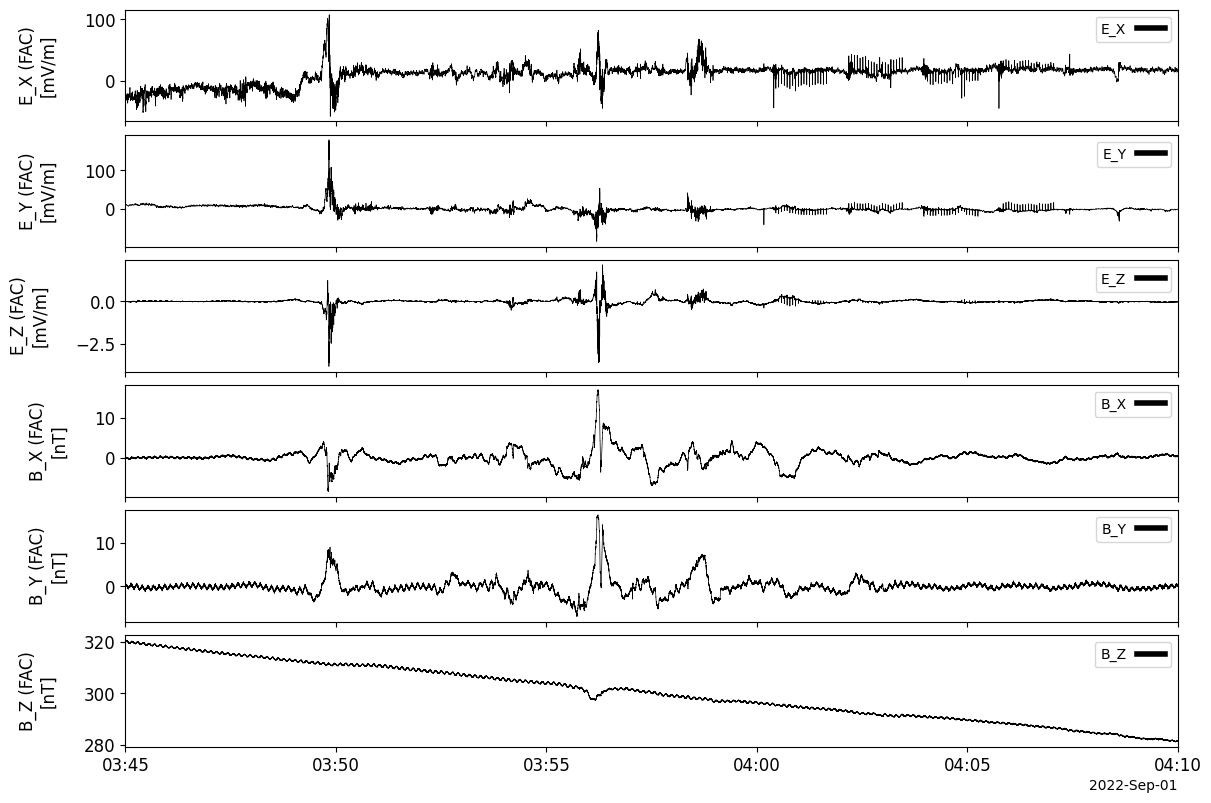

In [6]:
import pytplot as pt
import numpy as np

epoch = ds_fac.time.values.astype('datetime64[ns]').astype('int64') * 1e-9

for comp in ['x', 'y', 'z']:
    pt.store_data(f'E_fac_{comp}', data={'x': epoch, 'y': ds_fac[f'E{comp}_fac'].values})
    pt.store_data(f'B_fac_{comp}', data={'x': epoch, 'y': ds_fac[f'B{comp}_fac'].values})

    # 軸タイトルと凡例
    pt.options(f'E_fac_{comp}', 'ytitle', f'E_{comp.upper()} (FAC)\n[mV/m]')
    pt.options(f'B_fac_{comp}', 'ytitle', f'B_{comp.upper()} (FAC)\n[nT]')

    pt.options(f'E_fac_{comp}', 'legend_names', f'E_{comp.upper()}')
    pt.options(f'B_fac_{comp}', 'legend_names', f'B_{comp.upper()}')

    # 色の好みがあればここで指定
    # colors = dict(x='red', y='green', z='blue')
    # pt.options(f'Ex_fac_{comp}', 'color', colors[comp])
    # pt.options(f'Bx_fac_{comp}', 'color', colors[comp])

for comp in ['perp', 'para']:
    if comp == 'perp':
        ds_E = np.sqrt(ds_fac[f'Ex_fac'].values**2E0 + ds_fac[f'Ey_fac'].values**2E0)
        ds_B = np.sqrt(ds_fac[f'Bx_fac'].values**2E0 + ds_fac[f'By_fac'].values**2E0)
    elif comp == 'para':
        ds_E = ds_fac[f'Ez_fac'].values
        ds_B = ds_fac[f'Bz_fac'].values

    pt.store_data(f'E_fac_{comp}', data={'x': epoch, 'y': ds_E})
    pt.store_data(f'B_fac_{comp}', data={'x': epoch, 'y': ds_B})

    # 軸タイトルと凡例
    pt.options(f'E_fac_{comp}', 'ytitle', f'E_{comp.upper()} (FAC)\n[mV/m]')
    pt.options(f'B_fac_{comp}', 'ytitle', f'B_{comp.upper()} (FAC)\n[nT]')

    pt.options(f'E_fac_{comp}', 'legend_names', f'E_{comp.upper()}')
    pt.options(f'B_fac_{comp}', 'legend_names', f'B_{comp.upper()}')

# ------------------------------------------------------------
# 2. 個別パネルで描画
#    例: E_x/E_y/E_z、B_x/B_y/B_z の 6 行プロット
# ------------------------------------------------------------
pt.tplot([
    'E_fac_x', 'E_fac_y', 'E_fac_z',
    'B_fac_x', 'B_fac_y', 'B_fac_z'
])
#pt.tplot(
#    [
#        'E_fac_perp', 'E_fac_para', 'B_fac_perp', 'B_fac_para'
#    ]
#)

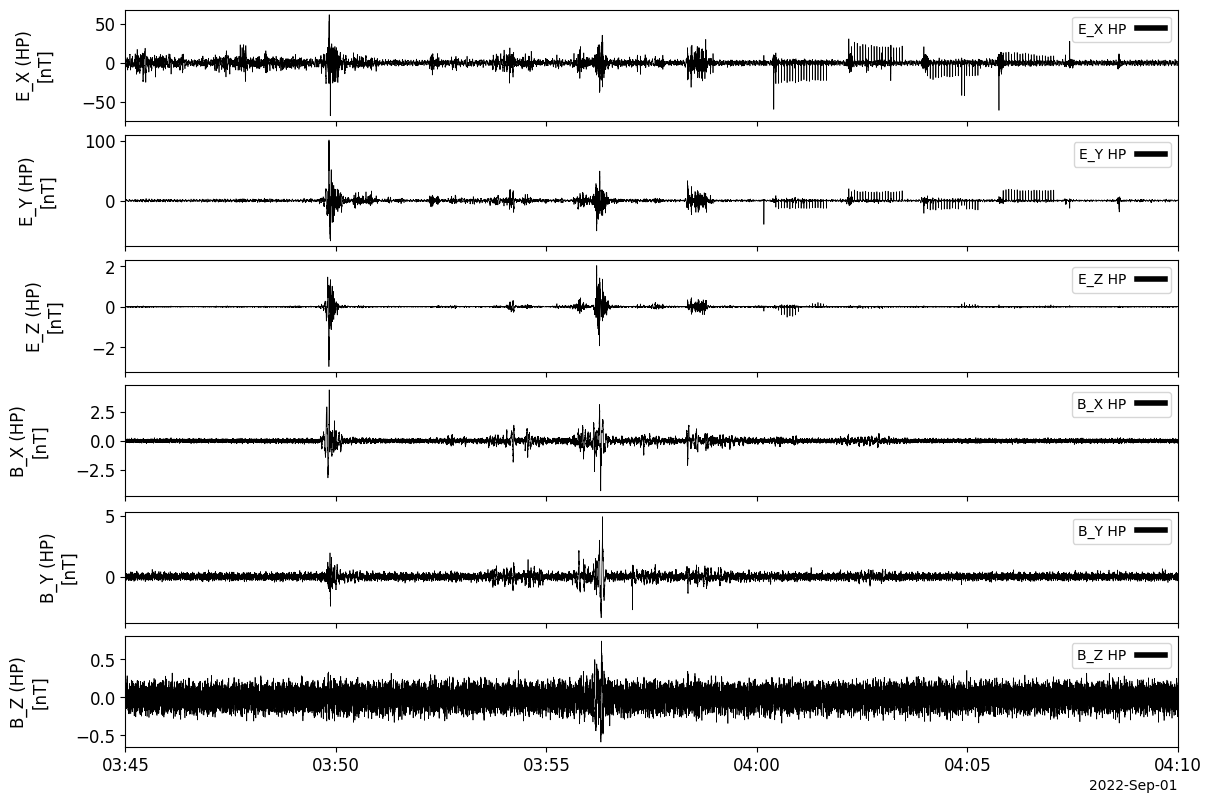

In [7]:
import numpy as np
from scipy.signal import butter, sosfiltfilt
import pytplot as pt

# ---------- 1. Butterworth ハイパス設定 -----------------------
fs      = 64.0              # サンプリング周波数 [Hz]
cutoff  = 1/6               # 0.25 Hz (spin 周期 8 s より少し高め)
sos     = butter(N=4, Wn=cutoff / (fs/2),
                 btype='high', output='sos')

def highpass_segmented(y, sos):
    """
    欠損(NaN) が混じる配列を NaN 区間で分割しつつ filtfilt する関数
    """
    good = np.isfinite(y)
    out  = np.full_like(y, np.nan)

    idx  = np.where(good)[0]
    segs = np.split(idx, np.where(np.diff(idx) != 1)[0] + 1)

    padlen = 3 * (sos.shape[0] - 1)   # filtfilt が要求する長さ

    for s in segs:
        if len(s) <= padlen:
            continue
        out[s] = sosfiltfilt(sos, y[s])
    return out

# ---------- 2. B_fac_* にフィルタを掛けて新変数を登録 ---------------
for comp in ['x', 'y', 'z']:
    for EB in ['E', 'B']:
        var_in  = f'{EB}_fac_{comp}'          # 元の tplot 変数
        da      = pt.data_quants[var_in]   # xarray.DataArray
        hp_data = highpass_segmented(da.data, sos)

        var_out = f'{var_in}_hp'           # 例: B_fac_x_hp
        pt.store_data(var_out,
                      data={'x': da.time.values, 'y': hp_data})

        # 軸/凡例調整 (お好み)
        pt.options(var_out, 'legend_names', f'{EB}_{comp.upper()} HP')
        pt.options(var_out, 'ytitle', f'{EB}_{comp.upper()} (HP)\n[nT]')

# ---------- 3. プロット -----------------------------------------------
pt.tplot(['E_fac_x_hp', 'E_fac_y_hp', 'E_fac_z_hp', 'B_fac_x_hp', 'B_fac_y_hp', 'B_fac_z_hp'])

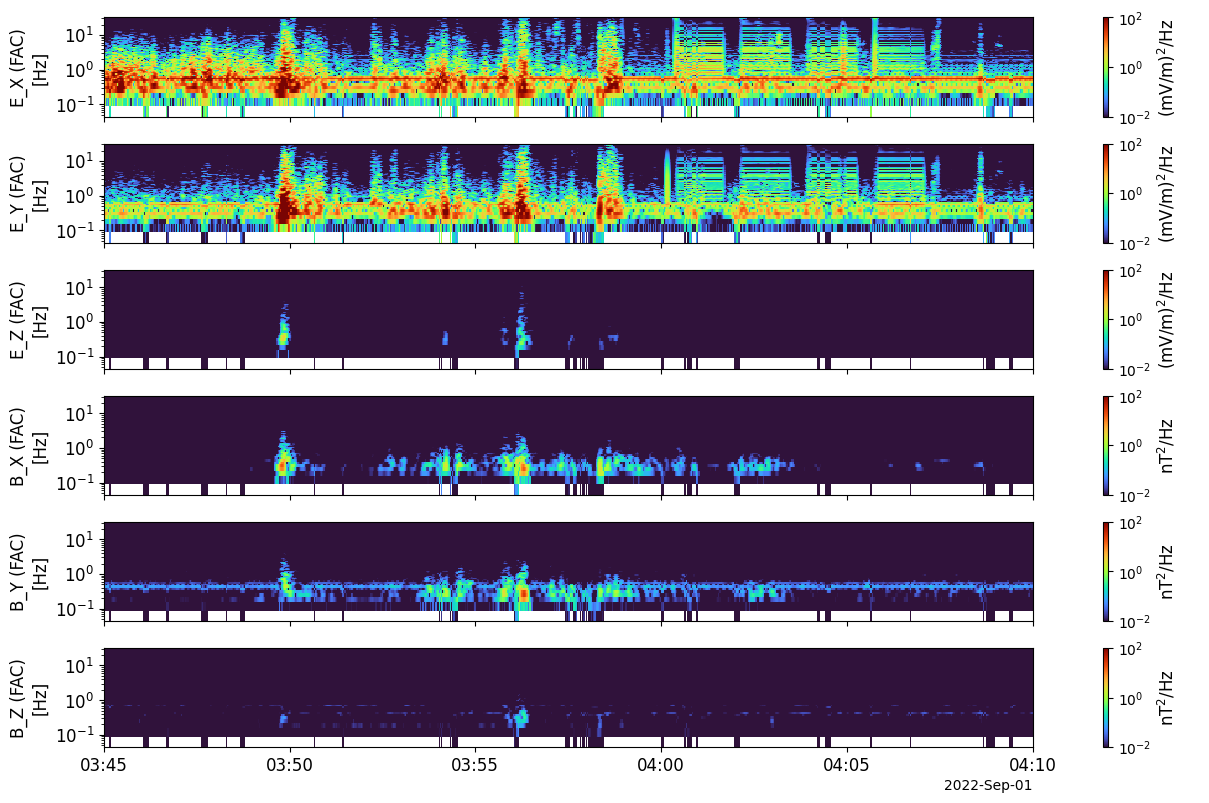

In [8]:
import pyspedas as psp
import pytplot as pt

# ------------------------------------------------------------
# 1. FFT / PSD を作成  ---------------------------------------
nbox   = 1024          # 64 Hz×1024 ≃ 16 s
nshift = nbox // 8     # 2 s シフト

for EB, unit in [('B', 'nT^2/Hz'), ('E', '(mV/m)^2/Hz')]:
    for comp in ['x', 'y', 'z']:
        var_in = f'{EB}_fac_{comp}_hp'               # 例: B_fac_x_hp
        if var_in not in pt.data_quants:             # 念のため存在チェック
            print(f'skip (no {var_in})')
            continue

        # PySPEDAS の FFT→dpwrspc 変数を作る
        psp.tdpwrspc(var_in, nboxpoints=nbox, nshiftpoints=nshift, bin=1)

        var_out = f'{var_in}_dpwrspc'                # 自動的に付く名前

        # 軸設定 --------------------------------------------------
        pt.options(var_out, 'ylog', 1)               # 周波数軸 log
        pt.options(var_out, 'ztitle', unit)
        pt.options(var_out, 'ytitle', f'{EB}_{comp.upper()} (FAC)')
        pt.options(var_out, 'colormap', 'turbo')
        # PSD のダイナミックレンジは適宜
        pt.options(var_out, 'zrange', [1e-2, 1e2])

# ------------------------------------------------------------
# 2. プロット  ------------------------------------------------
pt.tplot(['E_fac_x_hp_dpwrspc', 'E_fac_y_hp_dpwrspc', 'E_fac_z_hp_dpwrspc',
          'B_fac_x_hp_dpwrspc', 'B_fac_y_hp_dpwrspc', 'B_fac_z_hp_dpwrspc'])

In [9]:
import pyspedas as psp
import pytplot as pt

psp.erg.pwe_hfa(trange=time_range, level='l3')

14-Jul-25 16:00:29: Downloading remote index: https://ergsc.isee.nagoya-u.ac.jp/data/ergsc/satellite/erg/pwe/hfa/l3/2022/09/
14-Jul-25 16:00:29: Downloading https://ergsc.isee.nagoya-u.ac.jp/data/ergsc/satellite/erg/pwe/hfa/l3/2022/09/erg_pwe_hfa_l3_1min_20220901_v05_09.cdf to /mnt/j/observation_data//ergsc/satellite/erg/pwe/hfa/l3/2022/09/erg_pwe_hfa_l3_1min_20220901_v05_09.cdf
14-Jul-25 16:00:30: Download complete: /mnt/j/observation_data//ergsc/satellite/erg/pwe/hfa/l3/2022/09/erg_pwe_hfa_l3_1min_20220901_v05_09.cdf


 
 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Plasma Wave Experiment (PWE) High Frequency Analyzer (HFA) Level 3 UHR frequency and electron density data']

Information about ERG PWE HFA

PI:  ['Yoshiya Kasahara and Ayako Matsuoka']
Affiliation:  ['Kanazawa University and Kyoto University']

RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en
RoR of PWE/HFA: https://ergsc.isee.nagoya-u.ac.jp/mw/index.php/ErgSat/Pwe/Hfa

Contact: erg_pwe_info at isee.nagoya-u.ac.jp
**************************************************************************


['erg_pwe_hfa_l3_1min_Epoch',
 'erg_pwe_hfa_l3_1min_Fuhr',
 'erg_pwe_hfa_l3_1min_ne_mgf',
 'erg_pwe_hfa_l3_1min_quality_flag']

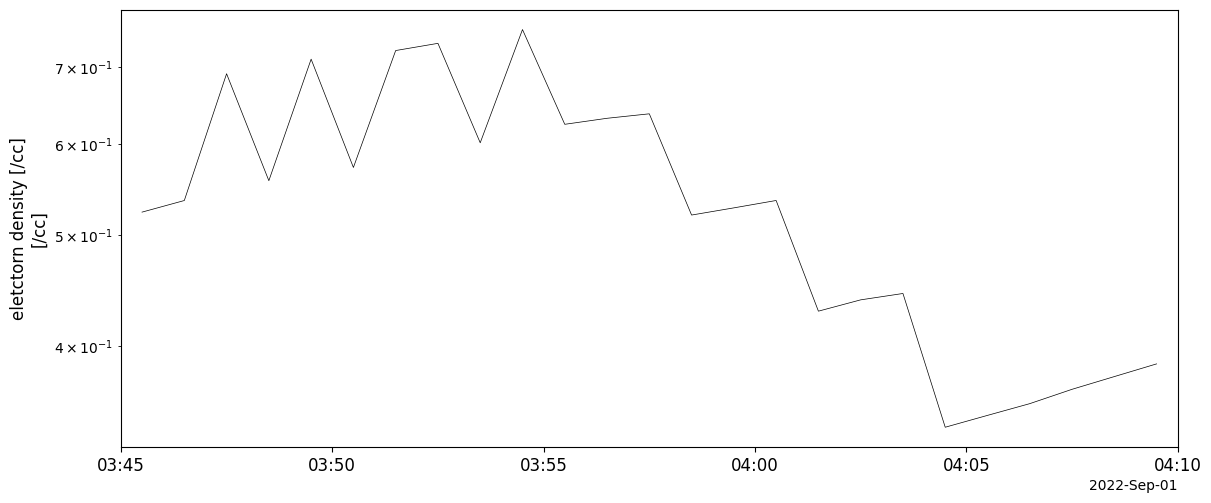

In [10]:
import pytplot as pt
pt.tplot(['erg_pwe_hfa_l3_1min_ne_mgf'])

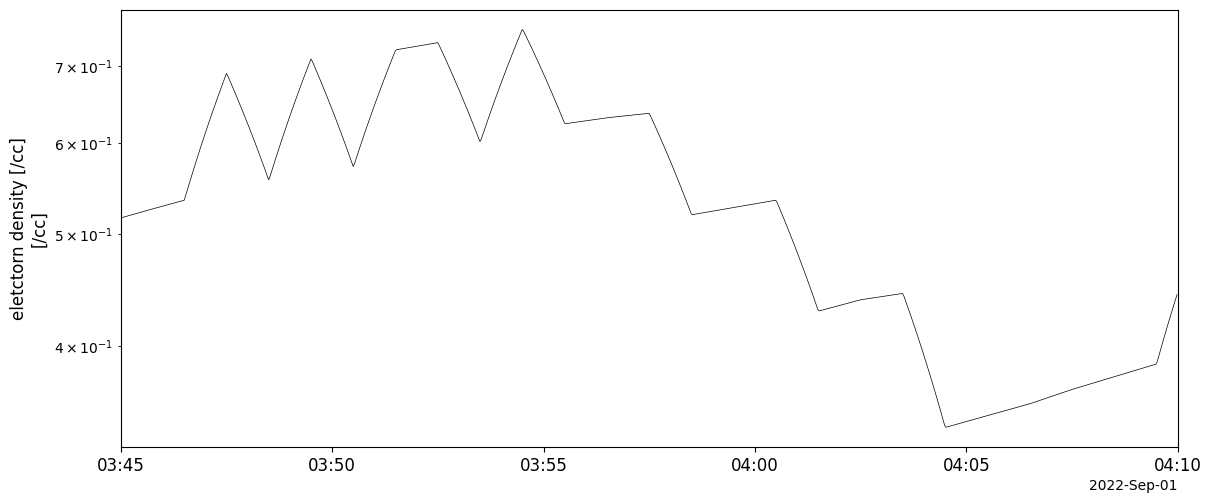

In [28]:
import pytplot as pt
number_density_l3 = pt.data_quants['erg_pwe_hfa_l3_1min_ne_mgf']
Bx_time = pt.data_quants['B_fac_x_hp_dpwrspc'].time
number_density_l3_i = number_density_l3.interp(time=Bx_time, method='linear')
pt.store_data('erg_pwe_hfa_l3_1min_ne_mgf_interp', data={'x': Bx_time.values, 'y': number_density_l3_i}, attr_dict=number_density_l3.attrs)
pt.tplot(['erg_pwe_hfa_l3_1min_ne_mgf_interp'])

14-Jul-25 16:52:00: avg_data was applied to: B_total_T-avg


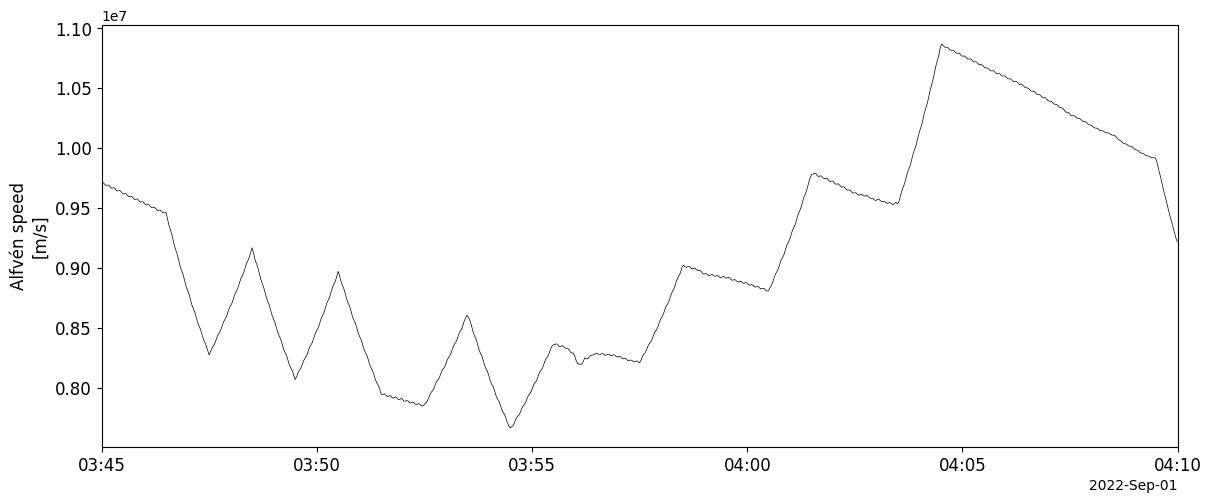

In [29]:
import numpy as np, pytplot as pt, xarray as xr
import pyspedas as psp

# --- 0. 時間範囲はすでに time_range_T で定義されている前提 ---------
Bx = pt.data_quants['B_fac_x'].sel(time=slice(*time_range_T))
By = pt.data_quants['B_fac_y'].sel(time=slice(*time_range_T))
Bz = pt.data_quants['B_fac_z'].sel(time=slice(*time_range_T))

# B_total [T]  (※ **2E0 は単に **2 でいい)
B_total = np.sqrt(Bx**2 + By**2 + Bz**2) * 1e-9      # nT → T
B_total.name = 'B_total_T'

# --- 1. density のケイデンス Δt を秒で推定 ---------------------------
density = number_density_l3_i.sel(time=slice(*time_range_T))
density_time = density.time.values

dt_ns = np.median(np.diff(density_time).astype('timedelta64[ns]').astype(float))
dt_sec = dt_ns * 1e-9          # 例: ≈ 4 s とか

# --- 2. B_total を同じ幅で移動平均し、density のタイムスタンプに補間 ---
# 2-1: tplot 変数にいったん登録（psp.avg_data を使う方法）
pt.store_data('B_total_T', data={'x': B_total.time.values,
                                 'y': B_total.values})
psp.avg_data('B_total_T', res=dt_sec)                 # → 'B_total_T-avg'

# 2-2: density の時刻に線形補間
B_total_avg = pt.data_quants['B_total_T-avg']
B_total_match = B_total_avg.interp(time=density_time)  # xarray の .interp

# --- 3. Alfvén 速度の計算 --------------------------------------------
mu0 = 4*np.pi*1e-7
mp  = 1.6726219e-27
n_i = density.values * 1e6           # cm⁻³ → m⁻³

v_A = B_total_match.values / np.sqrt(mu0 * mp * n_i)

pt.store_data('Alfven_speed',
              data={'x': density_time, 'y': v_A})
pt.options('Alfven_speed', 'ytitle', 'Alfvén speed')
pt.options('Alfven_speed', 'ysubtitle', '[m/s]')
pt.tplot('Alfven_speed')

In [53]:
print(pt.data_quants['Alfven_speed'].time)

<xarray.DataArray 'time' (time: 994)> Size: 8kB
array(['2022-09-01T03:40:58.046542080', '2022-09-01T03:41:00.045392128',
       '2022-09-01T03:41:02.044140032', ..., '2022-09-01T04:13:58.885583360',
       '2022-09-01T04:14:00.884369152', '2022-09-01T04:14:02.883219200'],
      shape=(994,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 8kB 2022-09-01T03:40:58.046542080 ... 2022...


14-Jul-25 17:38:53: Substituting symbol \perp from STIXGeneral
14-Jul-25 17:38:53: Substituting symbol \perp from STIXGeneral
14-Jul-25 17:38:53: Substituting symbol \perp from STIXGeneral
14-Jul-25 17:38:53: Substituting symbol \perp from STIXGeneral
14-Jul-25 17:38:53: Substituting symbol \perp from STIXGeneral
14-Jul-25 17:38:53: Substituting symbol \perp from STIXGeneral
14-Jul-25 17:38:53: Substituting symbol \perp from STIXGeneral
14-Jul-25 17:38:53: Substituting symbol \perp from STIXGeneral
14-Jul-25 17:38:53: Substituting symbol \perp from STIXGeneral
14-Jul-25 17:38:53: Substituting symbol \perp from STIXGeneral
14-Jul-25 17:38:53: Substituting symbol \perp from STIXGeneral
14-Jul-25 17:38:53: Substituting symbol \perp from STIXGeneral


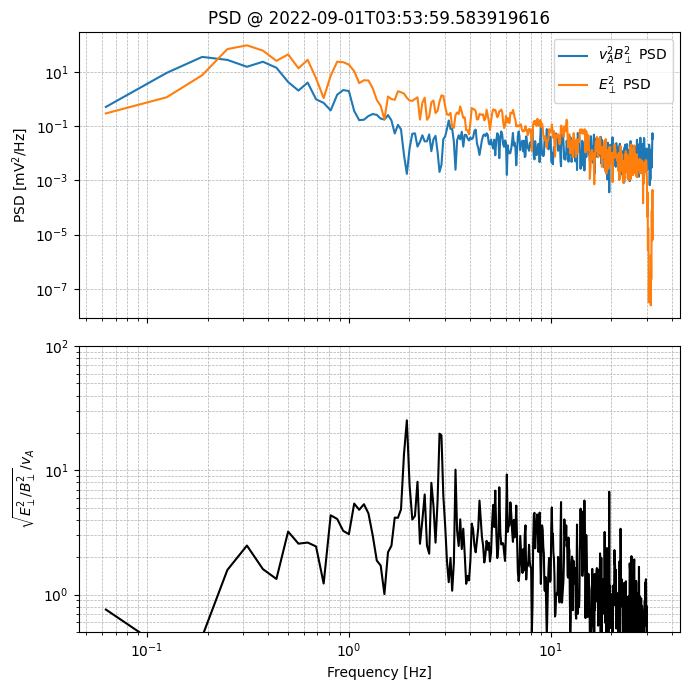

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import pytplot as pt
import matplotlib as mpl

mpl.rcdefaults()

target_time_str = '2022-09-01T03:54:00'

Bx_psd  = pt.data_quants['B_fac_x_hp_dpwrspc']
By_psd  = pt.data_quants['B_fac_y_hp_dpwrspc']
Ex_psd  = pt.data_quants['E_fac_x_hp_dpwrspc']
Ey_psd  = pt.data_quants['E_fac_y_hp_dpwrspc']
v_A_    = pt.data_quants['Alfven_speed']

t0      = np.datetime64(target_time_str)
idx     = np.argmin(np.abs(Bx_psd.time.values - t0))      # 最近傍インデックス
freq    = Bx_psd.spec_bins.values[0]                      # 周波数軸 [Hz]

B_perp2 = Bx_psd.values + By_psd.values
E_perp2 = Ex_psd.values + Ey_psd.values

# 1. 解析対象スロット（idx）の PSD を取り出し
B_perp2_slice = (Bx_psd[idx, :].values + By_psd[idx, :].values) * 1E-18         # [T^2/Hz]
E_perp2_slice = (Ex_psd[idx, :].values + Ey_psd[idx, :].values)                 # [(mV/m)^2/Hz]

# 2. 同時刻の Alfvén 速度を取得（cm-3 → m-3 換算済みのものを使っている前提）
v_A_val = v_A_.interp(time=t0).values      # [m/s]


# 3. v_A^2 * E_perp^2  を計算
#    E の単位が mV/m なら V/m へ換算する必要あり → (1e-3)^2 = 1e-6
VA2_Bperp2_slice = (v_A_val**2) * (B_perp2_slice) * 1E6     # [(mV/m)^2/Hz]

ratio_dimless = np.sqrt(E_perp2_slice * 1e-6 / B_perp2_slice) / v_A_val
#   E_perp2: (mV/m)² → (V/m)² に 1e-6 変換

# 4. プロット 2 枚（上下サブプロット） ------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 7), sharex=True,
                               gridspec_kw={'height_ratios': [1, 1]})

# --- (a) 既存の v_A²B⊥² と E⊥² -----------------------------------
ax1.loglog(freq, VA2_Bperp2_slice, label=r'$v_A^{2}B_\perp^{2}$ PSD')
ax1.loglog(freq, E_perp2_slice,    label=r'$E_\perp^{2}$ PSD')
ax1.set_ylabel(r'PSD [$\mathrm{mV}^{2}$/Hz]')
ax1.set_title(f'PSD @ {np.datetime_as_string(Bx_psd.time.values[idx], unit="ns")}')
ax1.grid(True, which='both', ls='--', lw=0.5)
ax1.legend()

# --- (b) 無次元比 √(E⊥²/B⊥²)/v_A -----------------------------------
ax2.loglog(freq, ratio_dimless, color='k')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylabel(r'$\sqrt{E_\perp^{2}/B_\perp^{2}}/v_A$')
ax2.grid(True, which='both', ls='--', lw=0.5)
ax2.set_ylim(5E-1, 1E2)

plt.tight_layout()
plt.show()

In [68]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pytplot as pt
import matplotlib as mpl

mpl.rcdefaults()

# ------------------------------------------------------------
# 0. 出力フォルダの用意
# ------------------------------------------------------------
out_dir = '/mnt/j/KAW_observation/E_B_ratio_ERG'
os.makedirs(out_dir, exist_ok=True)      # すでにあっても OK

# ------------------------------------------------------------
# 1. 対象データの読み出し
# ------------------------------------------------------------
Bx_psd = pt.data_quants['B_fac_x_hp_dpwrspc']
By_psd = pt.data_quants['B_fac_y_hp_dpwrspc']
Ex_psd = pt.data_quants['E_fac_x_hp_dpwrspc']
Ey_psd = pt.data_quants['E_fac_y_hp_dpwrspc']
v_A_   = pt.data_quants['Alfven_speed']

freq = Bx_psd.spec_bins.values[0]        # 共通周波数軸 [Hz]

# ------------------------------------------------------------
# 2. 解析対象の time_range を決めてループ
#    例: time_range = ['2022-09-01T03:49:00', '2022-09-01T03:59:00']
# ------------------------------------------------------------
time_range = ['2022-09-01T03:45:00', '2022-09-01T04:10:00']
t_min, t_max = map(np.datetime64, time_range)

for t in Bx_psd.time.values:
    if not (t_min <= t <= t_max):
        continue

    idx = np.argmin(np.abs(Bx_psd.time.values - t))

    # --- PSD スライス --------------------------------------------------
    B_perp2_slice = (Bx_psd[idx, :].values + By_psd[idx, :].values) * 1e-18  # [T²/Hz]
    E_perp2_slice = (Ex_psd[idx, :].values + Ey_psd[idx, :].values)          # [(mV/m)²/Hz]

    v_A_val = v_A_.interp(time=t).values

    VA2_Bperp2_slice = (v_A_val**2) * B_perp2_slice * 1e6                   # [(mV/m)²/Hz]
    ratio_dimless    = np.sqrt(E_perp2_slice * 1e-6 / B_perp2_slice) / v_A_val

    # --- プロット ------------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(7, 7), sharex=True,
        gridspec_kw={'height_ratios': [1, 1]}
    )

    ax1.loglog(freq, VA2_Bperp2_slice, label=r'$v_A^{2}B_\perp^{2}$ PSD')
    ax1.loglog(freq, E_perp2_slice,    label=r'$E_\perp^{2}$ PSD')
    ax1.set_ylabel(r'PSD [$\mathrm{mV}^{2}$/Hz]')
    ax1.set_title(f'PSD @ {np.datetime_as_string(t, unit="ns")}')
    ax1.grid(True, which='both', ls='--', lw=0.5)
    ax1.legend()

    ax2.loglog(freq, ratio_dimless, color='k')
    ax2.set_xlabel('Frequency [Hz]')
    ax2.set_ylabel(r'$\sqrt{E_\perp^{2}/B_\perp^{2}}/v_A$')
    ax2.grid(True, which='both', ls='--', lw=0.5)
    ax2.set_ylim(5e-1, 1e2)

    plt.tight_layout()

    # --- 画像保存 ------------------------------------------------------
    fname = f'{np.datetime_as_string(t, unit="ns")}.png'
    fig.savefig(os.path.join(out_dir, fname), dpi=200)
    plt.close(fig)      # メモリ解放

print('Finished saving all plots!')


14-Jul-25 19:22:38: Substituting symbol \perp from STIXGeneral
14-Jul-25 19:22:38: Substituting symbol \perp from STIXGeneral
14-Jul-25 19:22:38: Substituting symbol \perp from STIXGeneral
14-Jul-25 19:22:38: Substituting symbol \perp from STIXGeneral
14-Jul-25 19:22:38: Substituting symbol \perp from STIXGeneral
14-Jul-25 19:22:38: Substituting symbol \perp from STIXGeneral
14-Jul-25 19:22:38: Substituting symbol \perp from STIXGeneral
14-Jul-25 19:22:38: Substituting symbol \perp from STIXGeneral
14-Jul-25 19:22:38: Substituting symbol \perp from STIXGeneral
14-Jul-25 19:22:38: Substituting symbol \perp from STIXGeneral
14-Jul-25 19:22:38: Substituting symbol \perp from STIXGeneral
14-Jul-25 19:22:38: Substituting symbol \perp from STIXGeneral
14-Jul-25 19:22:39: Substituting symbol \perp from STIXGeneral
14-Jul-25 19:22:39: Substituting symbol \perp from STIXGeneral
14-Jul-25 19:22:39: Substituting symbol \perp from STIXGeneral
14-Jul-25 19:22:39: Substituting symbol \perp from STIX

Finished saving all plots!


In [ ]:
import os
from natsort import natsorted
import imageio                # ← v3 なら imageio.v2 を付けなくても同じ

img_dir = '/mnt/j/KAW_observation/E_B_ratio_ERG'
png_files = natsorted([os.path.join(img_dir, f)
                       for f in os.listdir(img_dir)
                       if f.lower().endswith('.png')])

frames = [imageio.imread(f) for f in png_files]
out_path = os.path.join(img_dir, 'E_B_ratio_ERG.mp4')

# codec は imageio-ffmpeg の同梱バイナリが自動で使われる
imageio.mimsave(out_path, frames, fps=5, codec='libx264')
print('saved to', out_path)

14-Jul-25 19:34:09: /tmp/ipykernel_31267/353087088.py:10: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames = [imageio.imread(f) for f in png_files]



14-Jul-25 19:34:41: IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1400, 1400) to (1408, 1408) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


saved to /mnt/j/KAW_observation/E_B_ratio_ERG/E_B_ratio_ERG.mp4


: 